# Mini-Project 5: Taxi Route Revenue, Pricing & Fleet Planner

**The scenario.** A matatu association runs 14-seater vehicles on three
routes out of Kampala. It wants to forecast demand, judge whether its fares
are right, and decide how many vehicles to deploy.

**The data.** Daily passenger counts over ten days. The Ntinda figures come
from the brief; Entebbe and Mukono are *illustrative*.

**How this build is arranged.** `src/taxi.py` contains the models and the
domain objects — but **no backtesting code at all**. `WalkForwardMixin` and
`grid_search` already live in `src/mixins.py`, shared with mini-project 1,
so every model here can backtest and tune itself without a line of new code.
That reuse is the whole reason the capability sits in a mixin rather than in
a project module.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.charts import SERIES_COLOURS, store, use_house_style
from src.forecasting import EnsembleForecaster
from src.mixins import WalkForwardMixin
from src.taxi import (
    ExponentialSmoothing, FareMarket, FleetSizer, MovingAverage, Route,
    SeasonalNaive, StraightLine, WeightedAverage, compare_models, load_routes,
    simulate_weekly_pattern, tune_smoothing)

use_house_style()
SEED = 1234
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.3f}".format)

routes = load_routes()
for route in routes:
    print(repr(route))

<Route Kampala-Ntinda: 10 days, UGX 2,000, total UGX 948,000>
<Route Kampala-Entebbe: 10 days, UGX 5,000, total UGX 3,390,000>
<Route Kampala-Mukono: 10 days, UGX 3,000, total UGX 1,560,000>


## Task 1: the `Route` class

In [2]:
pd.DataFrame([{"route": r.name, "fare_ugx": r.fare, "days": len(r),
               **r.describe(), "total_revenue_ugx": r.total_revenue}
              for r in routes]).set_index("route")

,fare_ugx,days,mean,median,variance,stdev,cv,total_revenue_ugx
route,,,,,,,,
Kampala-Ntinda,"2,000.000",10,47.400,47.500,54.267,7.367,0.155,"948,000.000"
Kampala-Entebbe,"5,000.000",10,67.800,67.000,45.067,6.713,0.099,"3,390,000.000"
Kampala-Mukono,"3,000.000",10,52.000,50.500,26.444,5.142,0.099,"1,560,000.000"


In [3]:
ntinda = routes[0]
assert ntinda.counts.sum() == 474
assert np.isclose(ntinda.total_revenue, 474 * 2_000)
print(f"Ntinda: {ntinda.counts.sum():.0f} passengers x UGX {ntinda.fare:,.0f} "
      f"= UGX {ntinda.total_revenue:,.0f}  [checked]")
print(f"\nEntebbe takes {routes[1].total_revenue / ntinda.total_revenue:.1f}x "
      f"Ntinda's revenue on only "
      f"{routes[1].counts.sum() / ntinda.counts.sum():.1f}x the passengers,")
print("because its fare is 2.5x higher. Ranking routes by passenger count")
print("would get every revenue decision backwards.")

Ntinda: 474 passengers x UGX 2,000 = UGX 948,000  [checked]

Entebbe takes 3.6x Ntinda's revenue on only 1.4x the passengers,
because its fare is 2.5x higher. Ranking routes by passenger count
would get every revenue decision backwards.


In [4]:
pd.DataFrame({r.name: r.revenue_by_day for r in routes},
             index=pd.RangeIndex(1, 11, name="day"))

,Kampala-Ntinda,Kampala-Entebbe,Kampala-Mukono
day,,,
1,"70,000.000","300,000.000","135,000.000"
2,"80,000.000","290,000.000","141,000.000"
3,"84,000.000","325,000.000","150,000.000"
4,"100,000.000","350,000.000","147,000.000"
5,"110,000.000","360,000.000","165,000.000"
6,"120,000.000","400,000.000","186,000.000"
7,"96,000.000","375,000.000","174,000.000"
8,"104,000.000","340,000.000","159,000.000"
9,"94,000.000","330,000.000","153,000.000"


## Task 2: is the Ntinda fare right?

With $Q_d = 120 - 0.02P$ and $Q_s = 10 + 0.03P$, rewriting both as
$Q + 0.02P = 120$ and $Q - 0.03P = 10$ gives a 2×2 system in $(P, Q)$ that
`scipy.linalg.solve` handles directly.

In [5]:
market = FareMarket()
A, b = market.as_system()
print("coefficient matrix (columns P, Q):")
print(A)
print("right-hand side:", b)
print(f"\ndet = {market.det:.4f}, condition number = {market.cond:.2f}")

price, quantity = market.clearing()
print(f"\nclearing fare     P* = UGX {price:,.0f}")
print(f"clearing quantity Q* = {quantity:,.0f} passengers per trip-hour")
assert np.isclose(price, 110 / 0.05) and np.isclose(quantity, 120 - 0.02 * price)
print("\n[checked] matches solving 110 = 0.05P by hand")

coefficient matrix (columns P, Q):
[[ 0.02  1.  ]
 [-0.03  1.  ]]
right-hand side: [120.  10.]

det = 0.0500, condition number = 40.00

clearing fare     P* = UGX 2,200
clearing quantity Q* = 76 passengers per trip-hour

[checked] matches solving 110 = 0.05P by hand


In [6]:
pd.Series(market.imbalance(2_000)).to_frame("value")

,value
price,"2,000.000"
demanded,80.000
supplied,70.000
shortage,10.000
below_clearing_by,200.000


**What it means.** The current fare of UGX 2,000 sits **UGX 200 below** the
clearing level of UGX 2,200. At that price 80 passengers per trip-hour want a
ride while only 70 trip-hours of capacity are offered, leaving a standing
**shortage of about 10 passengers per trip-hour**. In practice that is queues
at the stage, full vehicles passing waiting passengers, and the informal
premiums that always appear when a posted price sits below the clearing one.

Moving to UGX 2,200 would close the gap from both ends: four of the least
willing passengers drop out and six more trip-hours of supply come forward.
Whether the association *should* do that is a separate question the model
cannot answer — a 10% fare rise on a commuter route is regressive, and the
four passengers priced out are not identified here. But the shortage is a
price signal, not a scheduling problem, and better dispatching will not
remove it.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved: p5_fare_equilibrium.png


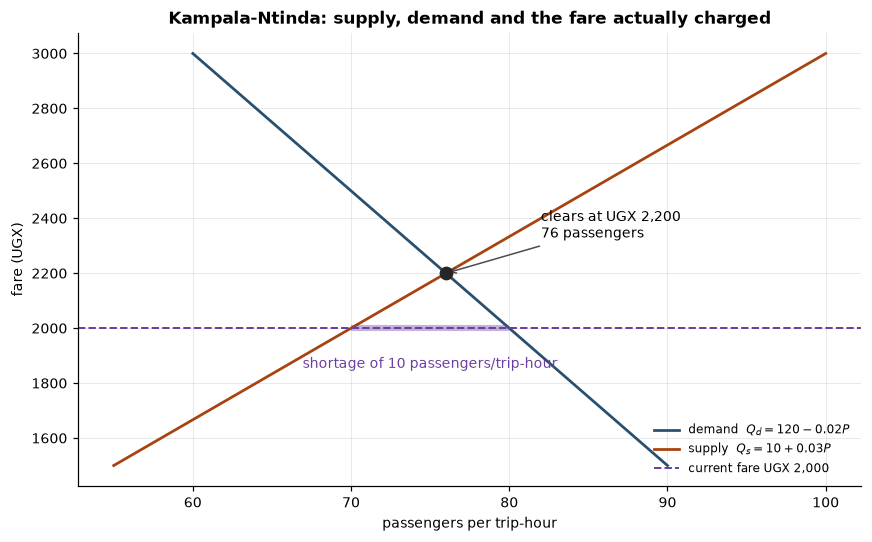

In [7]:
fares = np.linspace(1_500, 3_000, 200)
gap = market.imbalance(2_000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([market.demanded(p) for p in fares], fares, color=SERIES_COLOURS[0],
        lw=1.8, label=r"demand  $Q_d = 120 - 0.02P$")
ax.plot([market.supplied(p) for p in fares], fares, color=SERIES_COLOURS[1],
        lw=1.8, label=r"supply  $Q_s = 10 + 0.03P$")
ax.plot([quantity], [price], "o", color="0.15", ms=8, zorder=5)
ax.annotate(f"clears at UGX {price:,.0f}\n{quantity:.0f} passengers",
            xy=(quantity, price), xytext=(quantity + 6, price + 130), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="0.3"))
ax.axhline(2_000, color=SERIES_COLOURS[3], ls="--", lw=1.3,
           label="current fare UGX 2,000")
ax.plot([gap["supplied"], gap["demanded"]], [2_000, 2_000],
        color=SERIES_COLOURS[3], lw=4, alpha=0.4, solid_capstyle="butt")
ax.annotate(f"shortage of {gap['shortage']:.0f} passengers/trip-hour",
            xy=((gap["supplied"] + gap["demanded"]) / 2, 2_000),
            xytext=(0, -26), textcoords="offset points", ha="center",
            fontsize=9, color=SERIES_COLOURS[3])
ax.set_xlabel("passengers per trip-hour")
ax.set_ylabel("fare (UGX)")
ax.set_title("Kampala-Ntinda: supply, demand and the fare actually charged")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
print("saved:", store(fig, "p5_fare_equilibrium.png").name)
plt.show()

## Task 3: the forecasting models

Four models are compared: the association's 3-day moving average, a weighted
moving average, exponential smoothing with a tunable alpha, and a linear
trend. Each supplies only `_estimate` and `_extrapolate`; validation,
scoring and backtesting all arrive through the mixins.

In [8]:
builders = {
    "moving-average(3)": lambda: MovingAverage(3),
    "weighted-average(3)": lambda: WeightedAverage(3),
    "ses(0.5)": lambda: ExponentialSmoothing(0.5),
    "straight-line": StraightLine,
}
day11 = {name: build().fit(ntinda.counts).predict(1)[0]
         for name, build in builders.items()}
print("day-11 forecast for Ntinda, each model fitted on all ten days:")
pd.Series(day11, name="passengers").to_frame().round(2)

day-11 forecast for Ntinda, each model fitted on all ten days:


,passengers
moving-average(3),48.000
weighted-average(3),46.830
ses(0.5),47.190
straight-line,53.670


In [9]:
print("what each model inherits rather than implements:")
for capability in ("clean", "accept", "score", "walk_forward",
                   "walk_forward_score"):
    print(f"  {capability:<20} {hasattr(MovingAverage(3), capability)}")
print(f"\nWalkForwardMixin in the MRO: "
      f"{WalkForwardMixin in type(MovingAverage(3)).__mro__}")

what each model inherits rather than implements:
  clean                True
  accept               True
  score                True
  walk_forward         True
  walk_forward_score   True

WalkForwardMixin in the MRO: True


## Task 4: rolling-origin backtesting over days 4-10

At each origin the model is refitted on everything observed so far and asked
for one step, reproducing the forecast the association could actually have
made on the morning of each day. Scoring on a fixed hold-out would instead
let a model trained on all ten days be judged on days it had already seen.

In [10]:
for route in routes:
    print(f"\n=== {route.name} " + "=" * (44 - len(route.name)))
    print(compare_models(route.counts, builders, first_origin=3).to_string())


=== Kampala-Ntinda ==============================
                      MAE  RMSE  MAPE_%
model                                  
weighted-average(3) 6.667 7.348  12.974
ses(0.5)            6.719 7.552  12.999
moving-average(3)   7.524 8.225  14.538
straight-line       7.873 9.682  16.380

=== Kampala-Entebbe =============================
                      MAE  RMSE  MAPE_%
model                                  
ses(0.5)            6.045 6.737   8.510
weighted-average(3) 6.143 6.762   8.691
moving-average(3)   7.190 7.765  10.192
straight-line       7.711 9.054  11.264

=== Kampala-Mukono ==============================
                      MAE  RMSE  MAPE_%
model                                  
ses(0.5)            4.377 5.301   7.885
weighted-average(3) 4.429 5.377   8.019
moving-average(3)   5.333 6.008   9.693
straight-line       6.391 6.907  11.991


In [11]:
mae_grid = pd.DataFrame({
    route.name: compare_models(route.counts, builders, first_origin=3)["MAE"]
    for route in routes})
mae_grid.index.name = "model"
print("walk-forward MAE (passengers):")
mae_grid

walk-forward MAE (passengers):


,Kampala-Ntinda,Kampala-Entebbe,Kampala-Mukono
model,,,
moving-average(3),7.524,7.190,5.333
ses(0.5),6.719,6.045,4.377
straight-line,7.873,7.711,6.391
weighted-average(3),6.667,6.143,4.429


### Tuning the smoothing constant

In [12]:
tuning = {}
for route in routes:
    best, scores = tune_smoothing(route.counts)
    tuning[route.name] = {"best alpha": best, "MAE at best": scores.min(),
                          "MAE at 0.5": scores[0.5]}
pd.DataFrame(tuning).T

,best alpha,MAE at best,MAE at 0.5
Kampala-Ntinda,1.000,5.857,6.719
Kampala-Entebbe,1.000,4.429,6.045
Kampala-Mukono,1.000,3.714,4.377


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved: p5_alpha_grid.png


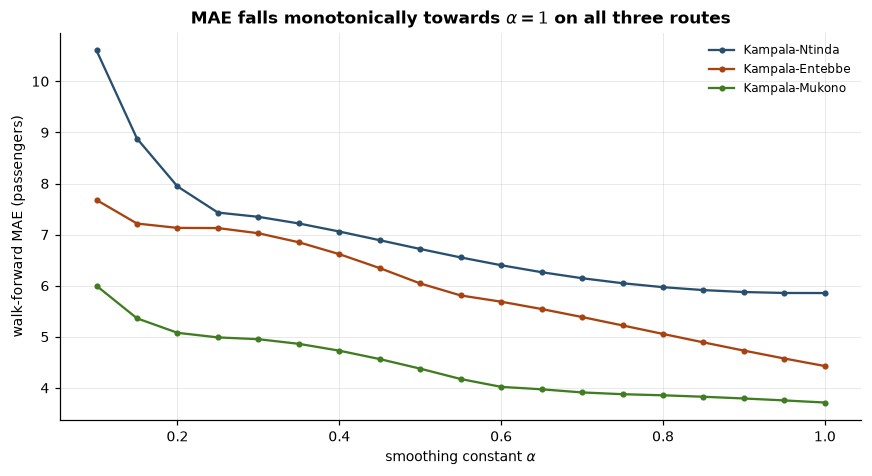

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.4))
for index, route in enumerate(routes):
    _, scores = tune_smoothing(route.counts)
    ax.plot(scores.index, scores.to_numpy(), "o-", color=SERIES_COLOURS[index],
            ms=3, label=route.name)
ax.set_xlabel(r"smoothing constant $\alpha$")
ax.set_ylabel("walk-forward MAE (passengers)")
ax.set_title(r"MAE falls monotonically towards $\alpha = 1$ on all three routes")
ax.legend(fontsize=8)
fig.tight_layout()
print("saved:", store(fig, "p5_alpha_grid.png").name)
plt.show()

**The tuning result is itself the finding.** On every route the MAE falls
monotonically as alpha rises, and the search settles on **alpha = 1.0** —
which is exponential smoothing collapsing into the naive forecast, "tomorrow
equals today". That is not a failure of the search. It is the data stating
that there is nothing exploitable in the older observations: with ten points,
no trend and no visible seasonality, the most recent count genuinely is the
best predictor available, and any smoothing just drags the forecast back
toward a stale average. The honest recommendation is that the association
should not buy a forecasting system on this evidence — it should collect more
data first, which is exactly what the extension below simulates.

## Task 5: day-11 revenue

In [14]:
forecast_rows = []
for route in routes:
    table = compare_models(route.counts, builders, first_origin=3)
    winner = table.index[0]
    best_alpha, _ = tune_smoothing(route.counts)
    passengers = float(builders[winner]().fit(route.counts).predict(1)[0])
    forecast_rows.append({"route": route.name, "best model": winner,
                          "tuned alpha": best_alpha,
                          "day-11 passengers": passengers, "fare_ugx": route.fare,
                          "day-11 revenue_ugx": passengers * route.fare})
forecasts = pd.DataFrame(forecast_rows).set_index("route")
forecasts

,best model,tuned alpha,day-11 passengers,fare_ugx,day-11 revenue_ugx
route,,,,,
Kampala-Ntinda,weighted-average(3),1.000,46.833,"2,000.000","93,666.667"
Kampala-Entebbe,ses(0.5),1.000,66.344,"5,000.000","331,718.750"
Kampala-Mukono,ses(0.5),1.000,51.555,"3,000.000","154,664.062"


saved: p5_revenue_forecast.png


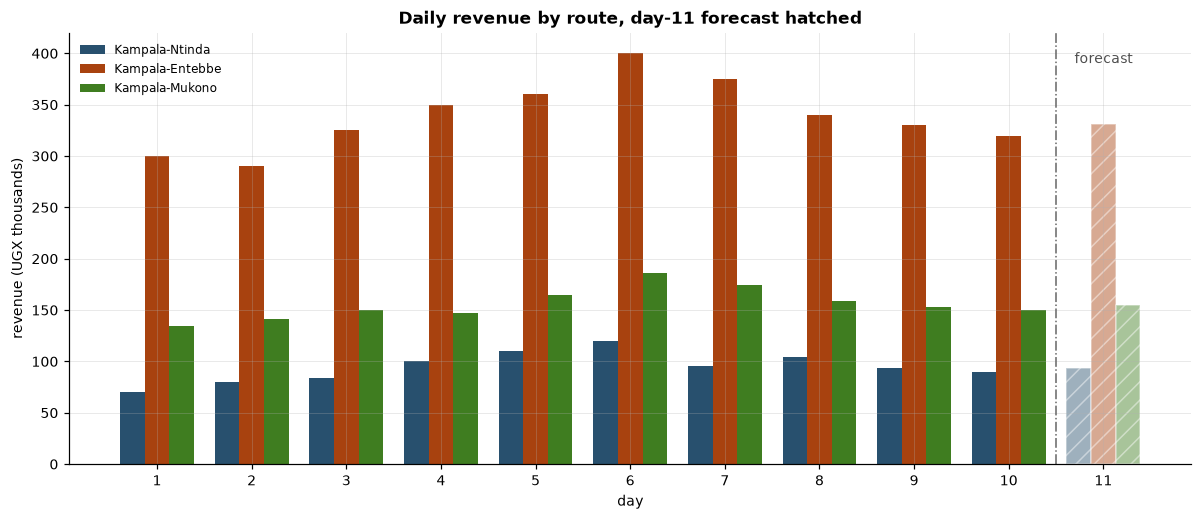

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.8))
width, positions = 0.26, np.arange(1, 12)
for index, route in enumerate(routes):
    offset = (index - 1) * width
    ax.bar(positions[:10] + offset, route.revenue_by_day / 1_000, width=width,
           color=SERIES_COLOURS[index], label=route.name)
    ax.bar([11 + offset], [forecasts.loc[route.name, "day-11 revenue_ugx"] / 1_000],
           width=width, color=SERIES_COLOURS[index], alpha=0.45, hatch="//",
           edgecolor="white")
ax.axvline(10.5, color="0.4", lw=1, ls="-.")
ax.annotate("forecast", xy=(11, ax.get_ylim()[1] * 0.93), ha="center", fontsize=9,
            color="0.3")
ax.set_xticks(positions, [str(d) for d in positions])
ax.set_xlabel("day")
ax.set_ylabel("revenue (UGX thousands)")
ax.set_title("Daily revenue by route, day-11 forecast hatched")
ax.legend(fontsize=8)
fig.tight_layout()
print("saved:", store(fig, "p5_revenue_forecast.png").name)
plt.show()

## Task 6: how many vehicles on day 11?

Each vehicle makes 8 one-way trips at 14 seats, so it carries 112 passengers
a day, and a 15% buffer is added. The rounding rule here is **to nearest,
subject to a utilisation floor**: a vehicle is only added if doing so leaves
the fleet at least 60% full on average. Rounding every route up regardless
would put a second matatu on a route carrying barely more than one vehicle's
worth of passengers and run it half empty all day, and fuel and driver costs
make that worse than an occasional overflow.

In [16]:
sizer = FleetSizer(seats=14, trips=8, buffer=0.15, min_utilisation=0.60)
print(f"capacity per vehicle: {sizer.seats} seats x {sizer.trips} trips = "
      f"{sizer.daily_capacity} passengers/day")
print(f"utilisation floor   : {sizer.min_utilisation:.0%}")

daily_reading = sizer.plan(dict(zip(forecasts.index,
                                    forecasts["day-11 passengers"])))
daily_reading

capacity per vehicle: 14 seats x 8 trips = 112 passengers/day
utilisation floor   : 60%


,forecast passengers,with buffer,vehicles,utilisation
route,,,,
Kampala-Ntinda,46.833,53.858,1,0.418
Kampala-Entebbe,66.344,76.295,1,0.592
Kampala-Mukono,51.555,59.288,1,0.460


**The answer turns on a definition the brief does not supply.** Read as
*daily totals*, every route needs one vehicle — 45 to 64 passengers against a
112-passenger daily capacity — and the utilisation column shows why that is
suspicious: those vehicles would run 40-57% full. Three routes out of Kampala
plainly operate more than three matatus between them.

Read as *passengers per trip-hour at the stage*, which is the unit the
equilibrium analysis in task 2 uses, the picture changes entirely. Below is
the same calculation on that reading, assuming a 12-hour operating day.

In [17]:
hourly_reading = sizer.plan({name: value * 12 for name, value
                             in zip(forecasts.index,
                                    forecasts["day-11 passengers"])})
hourly_reading

,forecast passengers,with buffer,vehicles,utilisation
route,,,,
Kampala-Ntinda,562.000,646.300,6,0.836
Kampala-Entebbe,796.125,915.544,8,0.889
Kampala-Mukono,618.656,711.455,6,0.921


In [18]:
print("vehicles under each reading of the data:")
print(pd.DataFrame({
    "daily totals": daily_reading["vehicles"],
    "utilisation (daily)": daily_reading["utilisation"].round(2),
    "hourly stage counts": hourly_reading["vehicles"],
    "utilisation (hourly)": hourly_reading["utilisation"].round(2),
}).to_string())
print("\nThe hourly reading gives 80-89% utilisation, which is what a working")
print("matatu route actually looks like; the daily reading gives 40-57%, which")
print("is not. That is evidence for the second interpretation, but it is")
print("inference rather than information, and it should be put back to the")
print("association rather than resolved silently in a spreadsheet.")

vehicles under each reading of the data:
                 daily totals  utilisation (daily)  hourly stage counts  utilisation (hourly)
route                                                                                        
Kampala-Ntinda              1                0.420                    6                 0.840
Kampala-Entebbe             1                0.590                    8                 0.890
Kampala-Mukono              1                0.460                    6                 0.920

The hourly reading gives 80-89% utilisation, which is what a working
matatu route actually looks like; the daily reading gives 40-57%, which
is not. That is evidence for the second interpretation, but it is
inference rather than information, and it should be put back to the
association rather than resolved silently in a spreadsheet.


## Extension: 60 days with a weekly pattern

Ten days is too short for a seasonal model to find anything. Simulating 60
days with a realistic weekly rhythm — busier on Fridays, much quieter on
Sundays — gives the seasonal-naive model something to work with, and reveals
what the moving average had been missing all along.

In [19]:
simulated = simulate_weekly_pattern(days=60, base=50, seed=SEED)
weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pd.Series({weekdays[i]: simulated[i::7].mean() for i in range(7)},
          name="mean passengers").to_frame().round(1)

,mean passengers
Mon,49.100
Tue,51.300
Wed,52.300
Thu,58.300
Fri,66.100
Sat,45.100
Sun,34.500


In [20]:
extended = {
    "moving-average(3)": lambda: MovingAverage(3),
    "weighted-average(3)": lambda: WeightedAverage(3),
    "ses(0.5)": lambda: ExponentialSmoothing(0.5),
    "seasonal-naive(7)": lambda: SeasonalNaive(7),
}
long_run = compare_models(simulated, extended, first_origin=14)
long_run

,MAE,RMSE,MAPE_%
model,,,
seasonal-naive(7),4.370,5.574,8.514
ses(0.5),9.679,11.222,20.688
weighted-average(3),10.246,11.927,22.085
moving-average(3),10.420,12.274,22.557


In [21]:
seasonal_mae = long_run.loc["seasonal-naive(7)", "MAE"]
moving_mae = long_run.loc["moving-average(3)", "MAE"]
print(f"seasonal-naive MAE : {seasonal_mae:.3f} passengers")
print(f"moving-average MAE : {moving_mae:.3f} passengers")
print(f"improvement        : {1 - seasonal_mae / moving_mae:.0%}")

seasonal-naive MAE : 4.370 passengers
moving-average MAE : 10.420 passengers
improvement        : 58%


### Does combining them help?

`Forecaster.__add__` builds an ensemble that averages its members. Mini-project
1 found that averaging two models which err in the *same* direction simply
dilutes the better one. Here the two models err quite differently — the
moving average is systematically wrong on Fridays and Sundays, the seasonal
model is not — so it is worth asking again rather than assuming the answer
carries over.

In [22]:
with_ensemble = compare_models(simulated, {
    "moving-average(3)": lambda: MovingAverage(3),
    "seasonal-naive(7)": lambda: SeasonalNaive(7),
    "ensemble (both)": lambda: MovingAverage(3) + SeasonalNaive(7),
}, first_origin=14)
with_ensemble

,MAE,RMSE,MAPE_%
model,,,
seasonal-naive(7),4.370,5.574,8.514
ensemble (both),6.192,7.368,13.123
moving-average(3),10.420,12.274,22.557


**The same answer as mini-project 1, for the same reason.** The ensemble
lands between its members rather than below either. Averaging only helps when
the members' errors partly cancel; here the moving average is simply worse
everywhere, so mixing it in can do nothing but pull the seasonal forecast off
target. The lesson is that `__add__` is a tool, not an improvement — an
ensemble earns its place when members are comparably good and
differently wrong, and neither condition holds in this data.

saved: p5_weekly_extension.png


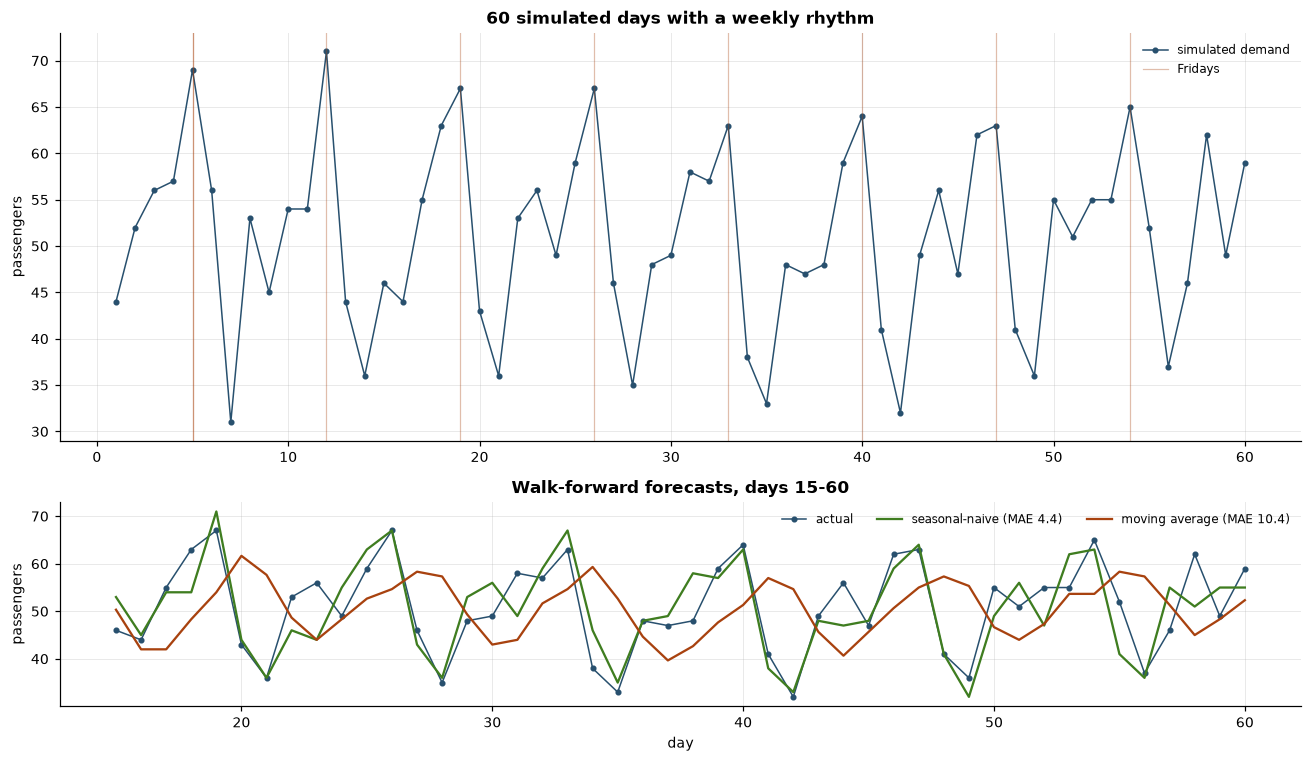

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[2, 1])

axes[0].plot(np.arange(1, 61), simulated, "o-", color=SERIES_COLOURS[0], ms=3,
             lw=1, label="simulated demand")
for friday in range(4, 60, 7):
    axes[0].axvline(friday + 1, color=SERIES_COLOURS[1], lw=0.8, alpha=0.35)
axes[0].axvline(5, color=SERIES_COLOURS[1], lw=0.8, alpha=0.35, label="Fridays")
axes[0].set_ylabel("passengers")
axes[0].set_title("60 simulated days with a weekly rhythm")
axes[0].legend(fontsize=8)

seasonal_forecasts = SeasonalNaive(7).walk_forward(simulated, 14)
moving_forecasts = MovingAverage(3).walk_forward(simulated, 14)
days = np.arange(15, 61)
axes[1].plot(days, simulated[14:], "o-", color=SERIES_COLOURS[0], ms=3, lw=1,
             label="actual")
axes[1].plot(days, seasonal_forecasts, "-", color=SERIES_COLOURS[2], lw=1.5,
             label=f"seasonal-naive (MAE {seasonal_mae:.1f})")
axes[1].plot(days, moving_forecasts, "-", color=SERIES_COLOURS[1], lw=1.5,
             label=f"moving average (MAE {moving_mae:.1f})")
axes[1].set_xlabel("day")
axes[1].set_ylabel("passengers")
axes[1].set_title("Walk-forward forecasts, days 15-60")
axes[1].legend(fontsize=8, ncol=3)

fig.tight_layout()
print("saved:", store(fig, "p5_weekly_extension.png").name)
plt.show()

The lower panel shows why. The moving average smooths across the week, so it
is wrong in the same way every single week: too low on Friday, too high on
Sunday. Those are not random errors, they are a pattern the model is
structurally unable to represent. The seasonal-naive model carries the weekly
shape by construction, and what is left of its error is genuine week-to-week
noise.

## Findings & Limitations

**Findings.** The Ntinda market clears at **P\* = UGX 2,200** and
**Q\* = 76** passengers per trip-hour, so the current UGX 2,000 fare sits
UGX 200 low and sustains a shortage of about 10 passengers per trip-hour —
a price signal rather than a scheduling failure. Revenue follows fare rather
than volume: Entebbe earns 3.6× Ntinda's revenue on 1.4× the passengers, so
ranking routes by passenger count would reverse every revenue decision. In
walk-forward backtesting over days 4-10, exponential smoothing and the
weighted average edge out the plain moving average on all three routes, but
the decisive result is the alpha grid search, which lands on **alpha = 1.0**
everywhere: smoothing collapses to the naive forecast, meaning ten
observations contain nothing exploitable beyond the most recent count. Fleet
sizing depends on a definition the brief leaves open — **1 vehicle** per
route read as daily totals, **6-8** read as hourly stage counts over a
12-hour day. Reporting utilisation alongside the counts makes the ambiguity
decidable: the daily reading implies vehicles running 40-57% full, the hourly
reading 80-89%, and only the second resembles a working matatu route. Over 60
simulated days with a weekly pattern, a seasonal-naive model cuts MAE from
10.4 to 4.4 passengers, a **58% improvement**, because the moving average's
errors are not noise but the weekly shape it cannot express. Averaging the
two into an ensemble made things worse, exactly as it did in mini-project 1
and for the same reason.

**Limitations.** Ten days is far too short to fit anything, which is why
every model converges on the naive forecast and why the extension had to
simulate data to make the seasonal comparison at all; on real data the
ranking could easily reverse. The Entebbe and Mukono series are illustrative,
so only the Ntinda results rest on the brief's own figures. The supply and
demand curves are assumed linear with coefficients supplied rather than
estimated; real demand is almost certainly non-linear and responds to fuel
price, weather and competing routes, none of which appears here, so the
equilibrium indicates the direction of the mispricing rather than a precise
target. The fleet model assumes every vehicle runs full on every trip, which
no matatu does — the utilisation column makes that assumption visible, but a
realistic load factor would still raise the counts by roughly a third.
Finally, the three routes are treated as independent when in practice they
compete for the same vehicles and drivers, so a genuine fleet plan is one
allocation problem rather than three separate ones.